# KSG Mutual Information — Test Suite

This notebook validates `ksg_mi` from `ami.py` using analytical,
numerical, nonlinear, invariance, quantization, and invalid-input
tests. Mutual information is reported in nats.

Finite-sample KSG estimates may be slightly negative when the true
mutual information is zero; this is estimator variance, not negative
theoretical mutual information.

In [1]:
import sys
from importlib import import_module
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.spatial import cKDTree


def find_repo_root(start):
    """Find the repository root."""
    for path in (start, *start.parents):
        if (path / "phase1" / "src").is_dir():
            return path
    raise FileNotFoundError("Repository root was not found.")


def gaussian_pair(n_samples, rho, seed):
    """Generate a standard correlated Gaussian pair."""
    rng = np.random.default_rng(seed)
    x = rng.normal(size=n_samples)
    residual = rng.normal(size=n_samples)
    y = rho * x + np.sqrt(1.0 - rho**2) * residual
    return x, y


def gaussian_mi(rho):
    """Return analytical Gaussian mutual information."""
    return float(-0.5 * np.log1p(-(rho**2)))


REPO_ROOT = find_repo_root(Path.cwd().resolve())
repo_path = str(REPO_ROOT)
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

ami = import_module("phase1.src.embedding.ami")
ksg_mi = ami.ksg_mi

BASE_SEED = 2026
K_DEFAULT = 3
N_REPEATS = 10
BLUE = "#0072B2"
ORANGE = "#D55E00"
GREEN = "#009E73"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 1.2,
})

## 1. Independent Gaussian — ground truth = 0

Estimate MI across increasing sample sizes and ten independent seeds.
The mean should remain near zero while dispersion decreases overall.

,N,mean_mi,std_mi,mean_absolute_mi
0,200,-0.01646,0.05667,0.04381
1,500,-0.00040,0.02248,0.01755
2,1000,0.00225,0.02882,0.02033
3,3000,0.00088,0.01131,0.00925
4,5000,-0.00173,0.01098,0.00835


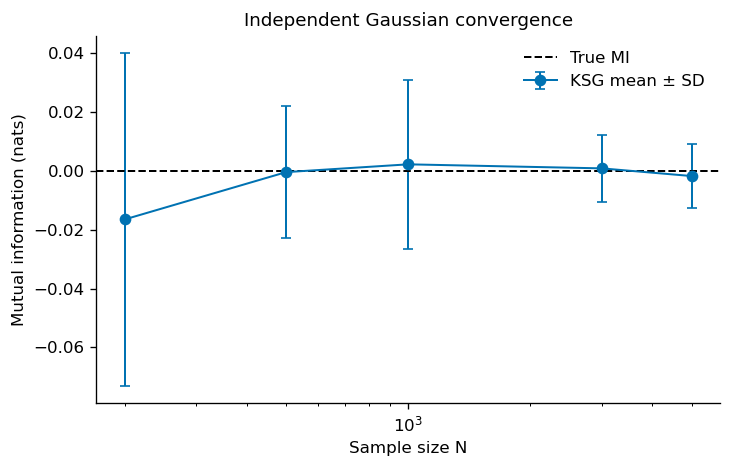

In [2]:
independent_sizes = np.array([200, 500, 1000, 3000, 5000])
independent_records = []

for n_samples in independent_sizes:
    estimates = []
    for repeat in range(N_REPEATS):
        rng = np.random.default_rng(BASE_SEED + repeat)
        x = rng.normal(size=n_samples)
        y = rng.normal(size=n_samples)
        estimates.append(ksg_mi(x, y, k=K_DEFAULT))

    independent_records.append({
        "N": n_samples,
        "mean_mi": np.mean(estimates),
        "std_mi": np.std(estimates, ddof=1),
        "mean_absolute_mi": np.mean(np.abs(estimates)),
    })

independent_table = pd.DataFrame(independent_records)
independent_ready = (
    abs(independent_table.iloc[-1]["mean_mi"]) < 0.03
    and independent_table.iloc[-1]["std_mi"]
    < independent_table.iloc[0]["std_mi"]
)
assert independent_ready
display(independent_table.round(5))

fig, ax = plt.subplots(figsize=(6.2, 4.0))
ax.errorbar(
    independent_table["N"],
    independent_table["mean_mi"],
    yerr=independent_table["std_mi"],
    color=BLUE,
    marker="o",
    capsize=3,
    label="KSG mean ± SD",
)
ax.axhline(0.0, color="black", linestyle="--", label="True MI")
ax.set(
    xscale="log",
    xlabel="Sample size N",
    ylabel="Mutual information (nats)",
    title="Independent Gaussian convergence",
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 2. Correlated Gaussian — analytical ground truth

For a standard bivariate Gaussian with correlation `rho`, the exact
mutual information is `-0.5 * ln(1 - rho²)`.

,rho,true_mi,estimated_mi,absolute_error
0,0.00,0.00000,-0.00056,0.00056
1,0.20,0.02041,0.01362,0.00679
2,0.50,0.14384,0.13698,0.00686
3,0.80,0.51083,0.50967,0.00115
4,0.95,1.16395,1.17117,0.00722


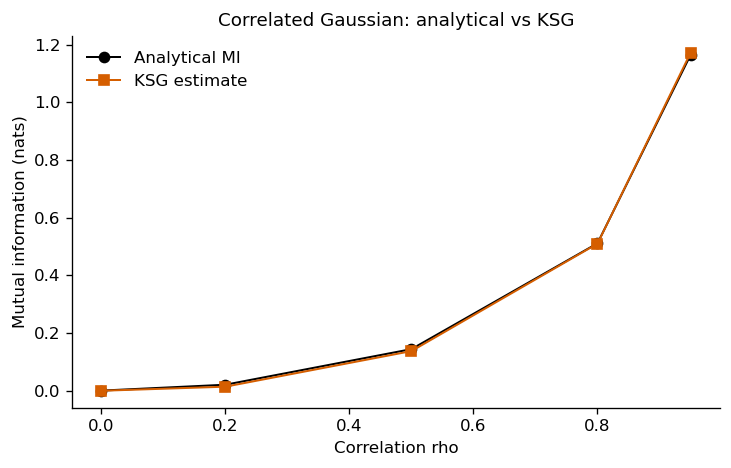

In [3]:
rho_values = np.array([0.0, 0.2, 0.5, 0.8, 0.95])
gaussian_records = []

for rho in rho_values:
    x, y = gaussian_pair(5000, rho, BASE_SEED)
    true_mi = gaussian_mi(rho)
    estimated_mi = ksg_mi(x, y, k=K_DEFAULT)
    gaussian_records.append({
        "rho": rho,
        "true_mi": true_mi,
        "estimated_mi": estimated_mi,
        "absolute_error": abs(estimated_mi - true_mi),
    })

gaussian_table = pd.DataFrame(gaussian_records)
gaussian_ready = gaussian_table["absolute_error"].max() < 0.03
assert gaussian_ready
display(gaussian_table.round(5))

fig, ax = plt.subplots(figsize=(6.2, 4.0))
ax.plot(
    gaussian_table["rho"],
    gaussian_table["true_mi"],
    color="black",
    marker="o",
    label="Analytical MI",
)
ax.plot(
    gaussian_table["rho"],
    gaussian_table["estimated_mi"],
    color=ORANGE,
    marker="s",
    label="KSG estimate",
)
ax.set(
    xlabel="Correlation rho",
    ylabel="Mutual information (nats)",
    title="Correlated Gaussian: analytical vs KSG",
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 3. Sample-size convergence

Keep `rho=0.7`, repeat ten seeds, and report the mean, standard
deviation, and bias relative to the analytical result.

,N,mean_estimated_mi,std_mi,bias
0,200,0.34962,0.04261,0.01295
1,500,0.34228,0.03650,0.00561
2,1000,0.34796,0.02898,0.01129
3,3000,0.34043,0.01614,0.00376
4,5000,0.33827,0.01534,0.00159


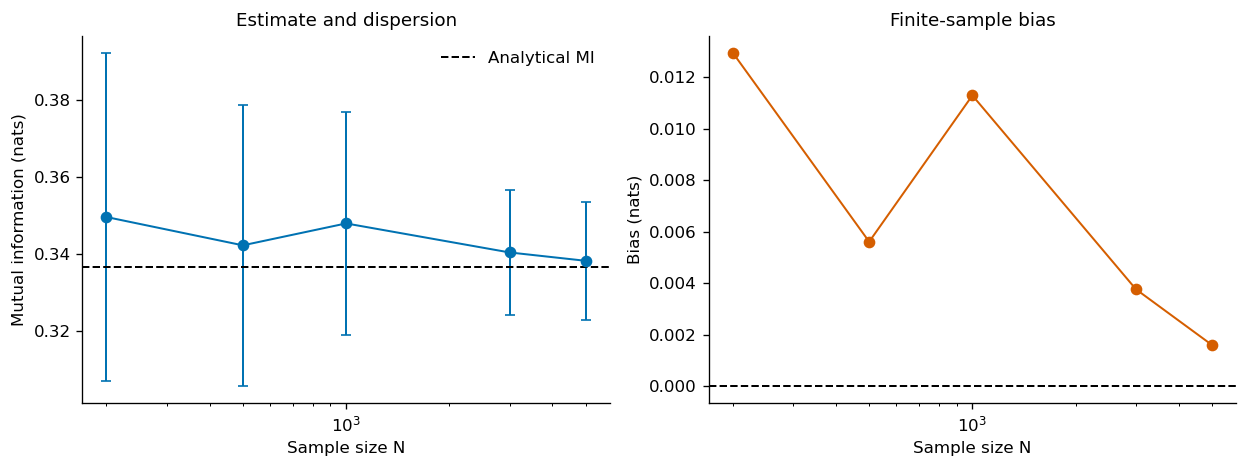

In [4]:
convergence_sizes = np.array([200, 500, 1000, 3000, 5000])
convergence_rho = 0.7
convergence_true = gaussian_mi(convergence_rho)
convergence_records = []

for n_samples in convergence_sizes:
    estimates = [
        ksg_mi(
            *gaussian_pair(
                n_samples,
                convergence_rho,
                BASE_SEED + repeat,
            ),
            k=K_DEFAULT,
        )
        for repeat in range(N_REPEATS)
    ]
    mean_estimate = np.mean(estimates)
    convergence_records.append({
        "N": n_samples,
        "mean_estimated_mi": mean_estimate,
        "std_mi": np.std(estimates, ddof=1),
        "bias": mean_estimate - convergence_true,
    })

convergence_table = pd.DataFrame(convergence_records)
convergence_ready = (
    convergence_table.iloc[-1]["std_mi"]
    < convergence_table.iloc[0]["std_mi"]
    and abs(convergence_table.iloc[-1]["bias"]) < 0.05
)
assert convergence_ready
display(convergence_table.round(5))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
axes[0].errorbar(
    convergence_table["N"],
    convergence_table["mean_estimated_mi"],
    yerr=convergence_table["std_mi"],
    color=BLUE,
    marker="o",
    capsize=3,
)
axes[0].axhline(
    convergence_true,
    color="black",
    linestyle="--",
    label="Analytical MI",
)
axes[0].set(
    xscale="log",
    xlabel="Sample size N",
    ylabel="Mutual information (nats)",
    title="Estimate and dispersion",
)
axes[0].legend(frameon=False)

axes[1].plot(
    convergence_table["N"],
    convergence_table["bias"],
    color=ORANGE,
    marker="o",
)
axes[1].axhline(0.0, color="black", linestyle="--")
axes[1].set(
    xscale="log",
    xlabel="Sample size N",
    ylabel="Bias (nats)",
    title="Finite-sample bias",
)
fig.tight_layout()
plt.show()

## 4. k sensitivity

Compare `k=2,3,4,5,10` at `rho=0.7` and `N=3000` over ten seeds.
This exposes the bias–variance trade-off rather than relying on one
random realization.

,k,mean_estimated_mi,std_mi,bias,absolute_error
0,2,0.33230,0.02286,-0.00437,0.00437
1,3,0.34043,0.01614,0.00376,0.00376
2,4,0.34204,0.01648,0.00537,0.00537
3,5,0.34032,0.01994,0.00365,0.00365
4,10,0.34365,0.01485,0.00697,0.00697


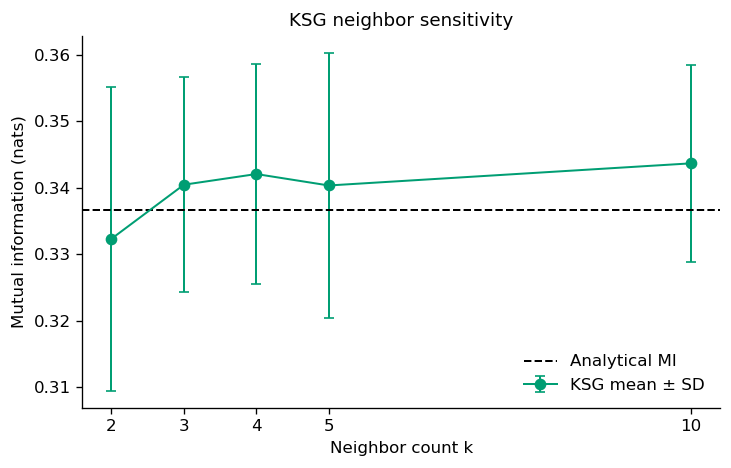

In [5]:
k_values = np.array([2, 3, 4, 5, 10])
k_true = gaussian_mi(0.7)
k_records = []

for k_value in k_values:
    estimates = [
        ksg_mi(
            *gaussian_pair(3000, 0.7, BASE_SEED + repeat),
            k=k_value,
        )
        for repeat in range(N_REPEATS)
    ]
    mean_estimate = np.mean(estimates)
    k_records.append({
        "k": k_value,
        "mean_estimated_mi": mean_estimate,
        "std_mi": np.std(estimates, ddof=1),
        "bias": mean_estimate - k_true,
        "absolute_error": abs(mean_estimate - k_true),
    })

k_table = pd.DataFrame(k_records)
stable_k = k_table[k_table["k"].isin([2, 3, 4])]
k_ready = stable_k["absolute_error"].max() < 0.05
assert k_ready
display(k_table.round(5))

fig, ax = plt.subplots(figsize=(6.2, 4.0))
ax.errorbar(
    k_table["k"],
    k_table["mean_estimated_mi"],
    yerr=k_table["std_mi"],
    color=GREEN,
    marker="o",
    capsize=3,
    label="KSG mean ± SD",
)
ax.axhline(
    k_true,
    color="black",
    linestyle="--",
    label="Analytical MI",
)
ax.set(
    xlabel="Neighbor count k",
    ylabel="Mutual information (nats)",
    title="KSG neighbor sensitivity",
)
ax.set_xticks(k_values)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 5. Nonlinear dependence

Generate `Y=X²+noise`. Pearson correlation should remain near zero,
while KSG detects dependence. Scaling the same noise realization
isolates the effect of increasing noise strength.

,noise_std,pearson_r,estimated_mi
0,0.1,-0.03831,1.97216
1,0.3,-0.04028,1.14506
2,0.7,-0.04191,0.60969
3,1.5,-0.03988,0.28049
4,3.0,-0.03402,0.11477


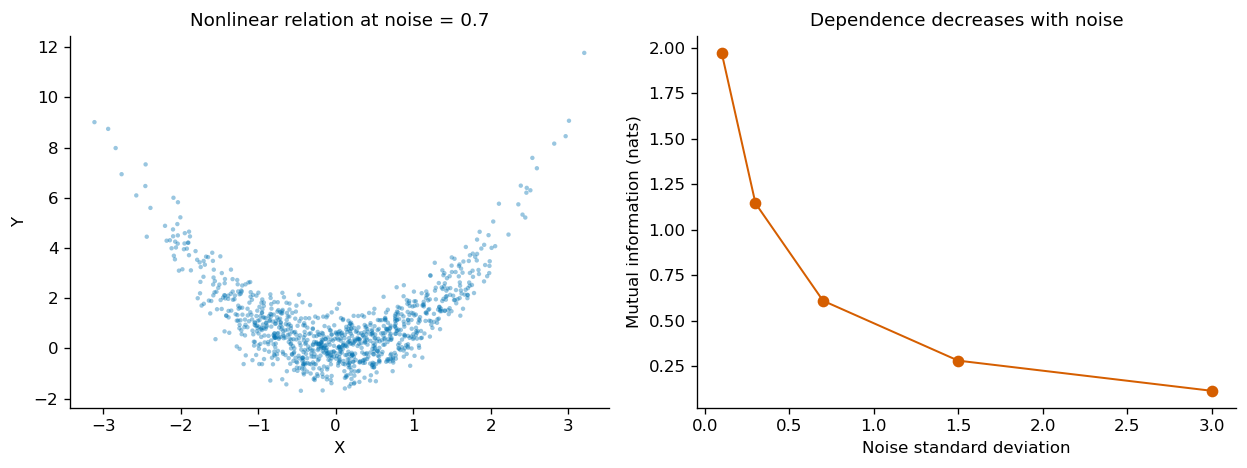

In [6]:
nonlinear_rng = np.random.default_rng(BASE_SEED)
nonlinear_x = nonlinear_rng.normal(size=5000)
nonlinear_noise = nonlinear_rng.normal(size=5000)
noise_levels = np.array([0.1, 0.3, 0.7, 1.5, 3.0])
nonlinear_records = []

for noise_level in noise_levels:
    nonlinear_y = (
        nonlinear_x**2 + noise_level * nonlinear_noise
    )
    nonlinear_records.append({
        "noise_std": noise_level,
        "pearson_r": np.corrcoef(
            nonlinear_x,
            nonlinear_y,
        )[0, 1],
        "estimated_mi": ksg_mi(
            nonlinear_x,
            nonlinear_y,
            k=K_DEFAULT,
        ),
    })

nonlinear_table = pd.DataFrame(nonlinear_records)
nonlinear_ready = (
    nonlinear_table["pearson_r"].abs().max() < 0.1
    and (np.diff(nonlinear_table["estimated_mi"]) < 0).all()
    and nonlinear_table.iloc[-1]["estimated_mi"] > 0.05
)
assert nonlinear_ready
display(nonlinear_table.round(5))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
preview_y = nonlinear_x**2 + 0.7 * nonlinear_noise
axes[0].scatter(
    nonlinear_x[::5],
    preview_y[::5],
    s=7,
    color=BLUE,
    alpha=0.4,
    edgecolors="none",
)
axes[0].set(
    xlabel="X",
    ylabel="Y",
    title="Nonlinear relation at noise = 0.7",
)
axes[1].plot(
    nonlinear_table["noise_std"],
    nonlinear_table["estimated_mi"],
    color=ORANGE,
    marker="o",
    label="KSG MI",
)
axes[1].set(
    xlabel="Noise standard deviation",
    ylabel="Mutual information (nats)",
    title="Dependence decreases with noise",
)
fig.tight_layout()
plt.show()

## 6. Invariance sanity check

Compare the baseline estimate with affine and exponential one-to-one
transforms. Exact invariance is theoretical; small differences are
expected from finite samples and neighbor geometry.

,estimate,mi,difference_from_baseline
0,"I(X, Y)",0.32813,0.00000
1,"I(2X + 5, Y)",0.34295,0.01481
2,"I(X, exp(Y))",0.33627,0.00814


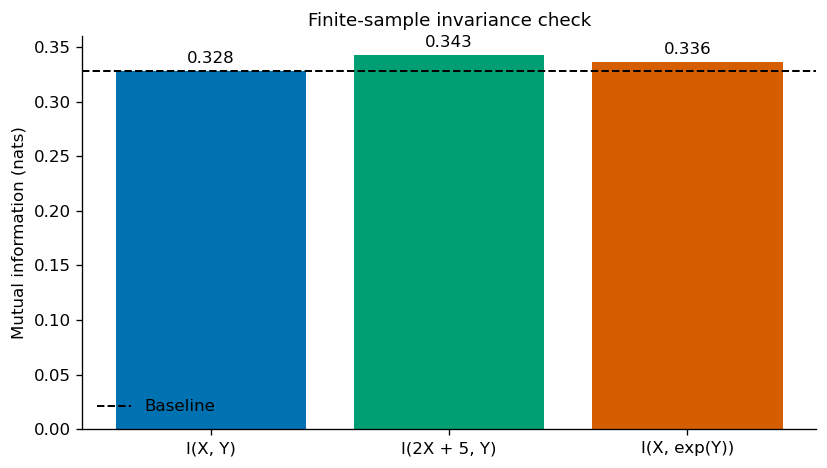

In [7]:
invariance_x, invariance_y = gaussian_pair(5000, 0.7, BASE_SEED)
baseline_mi = ksg_mi(invariance_x, invariance_y, k=K_DEFAULT)
invariance_records = [
    {
        "estimate": "I(X, Y)",
        "mi": baseline_mi,
        "difference_from_baseline": 0.0,
    },
    {
        "estimate": "I(2X + 5, Y)",
        "mi": ksg_mi(
            2.0 * invariance_x + 5.0,
            invariance_y,
            k=K_DEFAULT,
        ),
    },
    {
        "estimate": "I(X, exp(Y))",
        "mi": ksg_mi(
            invariance_x,
            np.exp(invariance_y),
            k=K_DEFAULT,
        ),
    },
]

for record in invariance_records[1:]:
    record["difference_from_baseline"] = record["mi"] - baseline_mi

invariance_table = pd.DataFrame(invariance_records)
invariance_ready = (
    invariance_table["difference_from_baseline"].abs().max() < 0.05
)
assert invariance_ready
display(invariance_table.round(5))

fig, ax = plt.subplots(figsize=(7.0, 4.0))
bars = ax.bar(
    invariance_table["estimate"],
    invariance_table["mi"],
    color=[BLUE, GREEN, ORANGE],
)
ax.axhline(
    baseline_mi,
    color="black",
    linestyle="--",
    label="Baseline",
)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set(
    ylabel="Mutual information (nats)",
    title="Finite-sample invariance check",
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 7. Quantization and jitter sensitivity

Round a correlated Gaussian pair to create exact ties. Count zero
joint k-neighbor radii, compare estimates with and without jitter,
and repeat the same seed to verify reproducibility.

,condition,zero_kth_radii,estimated_mi,absolute_error
0,No jitter,1665,0.120429,0.216244
1,"Jitter, seed 42",0,0.335037,0.001635
2,Repeated seed 42,0,0.335037,0.001635


MI change after jitter: 0.214609 nats


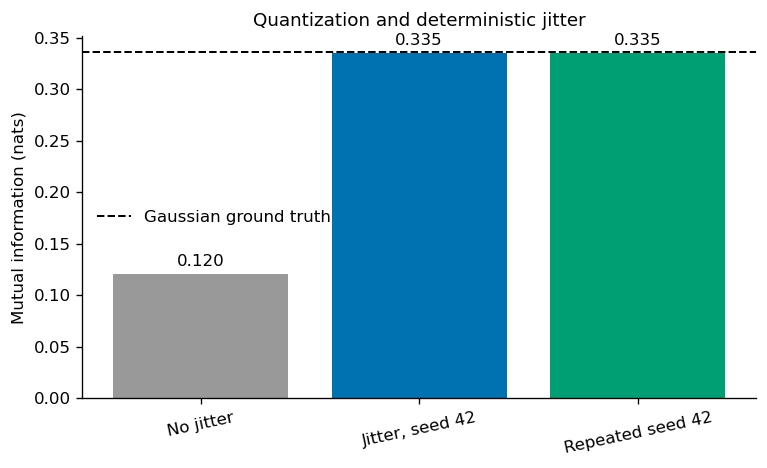

In [8]:
def add_jitter(x, y, amount, seed):
    """Apply the same jitter rule used by ksg_mi."""
    rng = np.random.default_rng(seed)
    x_jittered = x + rng.normal(
        0.0,
        amount * np.std(x),
        size=len(x),
    )
    y_jittered = y + rng.normal(
        0.0,
        amount * np.std(y),
        size=len(y),
    )
    return x_jittered, y_jittered


def count_zero_radii(x, y, k):
    """Count zero joint k-neighbor distances."""
    samples = np.column_stack((x, y))
    distances, _ = cKDTree(samples).query(
        samples,
        k=k + 1,
        p=np.inf,
    )
    return int(np.count_nonzero(distances[:, -1] == 0.0))


quantized_x, quantized_y = gaussian_pair(3000, 0.7, BASE_SEED)
quantized_x = np.round(quantized_x, 1)
quantized_y = np.round(quantized_y, 1)
jitter_amount = 1e-10
jitter_seed = 42

zero_radii_no_jitter = count_zero_radii(
    quantized_x,
    quantized_y,
    K_DEFAULT,
)
jittered_x, jittered_y = add_jitter(
    quantized_x,
    quantized_y,
    jitter_amount,
    jitter_seed,
)
zero_radii_with_jitter = count_zero_radii(
    jittered_x,
    jittered_y,
    K_DEFAULT,
)

no_jitter_mi = ksg_mi(
    quantized_x,
    quantized_y,
    k=K_DEFAULT,
    jitter=0.0,
)
jittered_mi = ksg_mi(
    quantized_x,
    quantized_y,
    k=K_DEFAULT,
    jitter=jitter_amount,
    random_state=jitter_seed,
)
repeated_mi = ksg_mi(
    quantized_x,
    quantized_y,
    k=K_DEFAULT,
    jitter=jitter_amount,
    random_state=jitter_seed,
)
quantized_true = gaussian_mi(0.7)

quantization_table = pd.DataFrame([
    {
        "condition": "No jitter",
        "zero_kth_radii": zero_radii_no_jitter,
        "estimated_mi": no_jitter_mi,
        "absolute_error": abs(no_jitter_mi - quantized_true),
    },
    {
        "condition": "Jitter, seed 42",
        "zero_kth_radii": zero_radii_with_jitter,
        "estimated_mi": jittered_mi,
        "absolute_error": abs(jittered_mi - quantized_true),
    },
    {
        "condition": "Repeated seed 42",
        "zero_kth_radii": zero_radii_with_jitter,
        "estimated_mi": repeated_mi,
        "absolute_error": abs(repeated_mi - quantized_true),
    },
])
mi_change = jittered_mi - no_jitter_mi
jitter_ready = (
    zero_radii_no_jitter > 0
    and zero_radii_with_jitter == 0
    and jittered_mi == repeated_mi
    and quantization_table.iloc[1]["absolute_error"]
    < quantization_table.iloc[0]["absolute_error"]
)
assert jitter_ready
display(quantization_table.round(6))
print(f"MI change after jitter: {mi_change:.6f} nats")

fig, ax = plt.subplots(figsize=(6.5, 4.0))
bars = ax.bar(
    quantization_table["condition"],
    quantization_table["estimated_mi"],
    color=["#999999", BLUE, GREEN],
)
ax.axhline(
    quantized_true,
    color="black",
    linestyle="--",
    label="Gaussian ground truth",
)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set(
    ylabel="Mutual information (nats)",
    title="Quantization and deterministic jitter",
)
ax.tick_params(axis="x", rotation=12)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 8. Edge cases

Each invalid input must raise the expected exception with a clear
message.

In [9]:
def capture_error(name, function, expected_type):
    """Run an invalid case and capture its expected error."""
    try:
        function()
    except expected_type as error:
        return {
            "case": name,
            "status": "PASS",
            "exception": type(error).__name__,
            "message": str(error),
        }
    except Exception as error:
        raise AssertionError(
            f"{name} raised {type(error).__name__}, "
            f"expected {expected_type.__name__}."
        ) from error
    raise AssertionError(f"{name} did not raise an exception.")


valid_x = np.arange(10, dtype=float)
valid_y = valid_x[::-1].copy()
edge_cases = [
    (
        "Different lengths",
        lambda: ksg_mi(valid_x, valid_y[:-1]),
        ValueError,
    ),
    (
        "2D input",
        lambda: ksg_mi(valid_x[:, None], valid_y),
        ValueError,
    ),
    (
        "NaN",
        lambda: ksg_mi(
            np.array([0.0, 1.0, np.nan, 3.0]),
            np.arange(4.0),
        ),
        ValueError,
    ),
    (
        "Inf",
        lambda: ksg_mi(
            np.array([0.0, 1.0, np.inf, 3.0]),
            np.arange(4.0),
        ),
        ValueError,
    ),
    (
        "Zero variance",
        lambda: ksg_mi(np.ones(10), valid_y),
        ValueError,
    ),
    (
        "k < 1",
        lambda: ksg_mi(valid_x, valid_y, k=0),
        ValueError,
    ),
    (
        "N <= k",
        lambda: ksg_mi(valid_x[:3], valid_y[:3], k=3),
        ValueError,
    ),
    (
        "Negative jitter",
        lambda: ksg_mi(valid_x, valid_y, jitter=-1e-6),
        ValueError,
    ),
]

edge_results = [
    capture_error(name, function, expected_type)
    for name, function, expected_type in edge_cases
]
edge_table = pd.DataFrame(edge_results)
edge_ready = edge_table["status"].eq("PASS").all()
assert edge_ready
display(edge_table)

,case,status,exception,message
0,Different lengths,PASS,ValueError,x and y must have the same length.
1,2D input,PASS,ValueError,x and y must be 1D arrays.
2,NaN,PASS,ValueError,x and y must contain only finite values.
3,Inf,PASS,ValueError,x and y must contain only finite values.
4,Zero variance,PASS,ValueError,x must have non-zero variance.
5,k < 1,PASS,ValueError,k must be at least 1.
6,N <= k,PASS,ValueError,Number of samples must be greater than k.
7,Negative jitter,PASS,ValueError,jitter must be non-negative.


## Ready-to-freeze summary

Consolidated executable acceptance checks for the current KSG core.

In [10]:
freeze_checks = {
    "Independent Gaussian MI is near zero": independent_ready,
    "Analytical Gaussian MI is reproduced": gaussian_ready,
    "Sample-size convergence is acceptable": convergence_ready,
    "Estimates are stable around k=2-4": k_ready,
    "Nonlinear dependence is detected": nonlinear_ready,
    "One-to-one transforms are approximately invariant": (
        invariance_ready
    ),
    "Jitter resolves quantization ties reproducibly": jitter_ready,
    "All edge cases fail clearly": edge_ready,
}

assert all(freeze_checks.values())
freeze_table = pd.DataFrame({
    "criterion": freeze_checks.keys(),
    "status": [
        "PASS" if passed else "FAIL"
        for passed in freeze_checks.values()
    ],
})
display(freeze_table)
print("KSG mutual information is ready to freeze for this design.")

,criterion,status
0,Independent Gaussian MI is near zero,PASS
1,Analytical Gaussian MI is reproduced,PASS
2,Sample-size convergence is acceptable,PASS
3,Estimates are stable around k=2-4,PASS
4,Nonlinear dependence is detected,PASS
5,One-to-one transforms are approximately invariant,PASS
6,Jitter resolves quantization ties reproducibly,PASS
7,All edge cases fail clearly,PASS


KSG mutual information is ready to freeze for this design.


# Final Report — KSG Mutual Information

## Test configuration

- Estimator: KSG Algorithm 1, output in nats.
- Default neighbor count: `k=3`.
- Repeated experiments: 10 deterministic seeds.
- Main random seed: `2026`.
- Analytical Gaussian reference:
  `I(X;Y) = -0.5 ln(1-rho²)`.

## 1. Independent Gaussian

| N | Mean MI | Standard deviation | Mean absolute MI |
|---:|---:|---:|---:|
| 200 | -0.01646 | 0.05667 | 0.04381 |
| 500 | -0.00040 | 0.02248 | 0.01755 |
| 1000 | 0.00225 | 0.02882 | 0.02033 |
| 3000 | 0.00088 | 0.01131 | 0.00925 |
| 5000 | -0.00173 | 0.01098 | 0.00835 |

The estimate remains near the theoretical value of zero. Dispersion
decreases substantially between `N=200` and `N=5000`. Small negative
values are finite-sample estimator variation, not negative theoretical
mutual information.

## 2. Correlated Gaussian

| rho | Analytical MI | KSG MI | Absolute error |
|---:|---:|---:|---:|
| 0.00 | 0.00000 | -0.00056 | 0.00056 |
| 0.20 | 0.02041 | 0.01362 | 0.00679 |
| 0.50 | 0.14384 | 0.13698 | 0.00686 |
| 0.80 | 0.51083 | 0.50967 | 0.00115 |
| 0.95 | 1.16395 | 1.17117 | 0.00722 |

Maximum absolute error is `0.00722` nats. KSG closely reproduces the
analytical Gaussian curve across weak to strong correlation.

## 3. Sample-size convergence at rho = 0.7

The analytical MI is approximately `0.33667` nats.

| N | Mean estimated MI | Standard deviation | Bias |
|---:|---:|---:|---:|
| 200 | 0.34962 | 0.04261 | 0.01295 |
| 500 | 0.34228 | 0.03650 | 0.00561 |
| 1000 | 0.34796 | 0.02898 | 0.01129 |
| 3000 | 0.34043 | 0.01614 | 0.00376 |
| 5000 | 0.33827 | 0.01534 | 0.00159 |

Variance decreases overall as sample size grows. At `N=5000`, the
remaining bias is approximately `0.00159` nats.

## 4. Neighbor-count sensitivity

| k | Mean estimated MI | Standard deviation | Absolute error |
|---:|---:|---:|---:|
| 2 | 0.33230 | 0.02286 | 0.00437 |
| 3 | 0.34043 | 0.01614 | 0.00376 |
| 4 | 0.34204 | 0.01648 | 0.00537 |
| 5 | 0.34032 | 0.01994 | 0.00365 |
| 10 | 0.34365 | 0.01485 | 0.00697 |

Results are stable around `k=2–4`. Larger `k` reduces local variance
but may increase smoothing bias. The default `k=3` is acceptable for
the tested sample sizes.

## 5. Nonlinear dependence

| Noise standard deviation | Pearson r | KSG MI |
|---:|---:|---:|
| 0.1 | -0.03831 | 1.97216 |
| 0.3 | -0.04028 | 1.14506 |
| 0.7 | -0.04191 | 0.60969 |
| 1.5 | -0.03988 | 0.28049 |
| 3.0 | -0.03402 | 0.11477 |

Pearson correlation remains close to zero for `Y=X²+noise`, while KSG
detects strong nonlinear dependence. Estimated MI decreases
monotonically as noise increases.

## 6. Invariance sanity check

| Estimate | MI | Difference from baseline |
|:--|---:|---:|
| `I(X,Y)` | 0.32813 | 0.00000 |
| `I(2X+5,Y)` | 0.34295 | 0.01481 |
| `I(X,exp(Y))` | 0.33627 | 0.00814 |

The largest finite-sample difference is `0.01481` nats. This is within
the accepted tolerance of `0.05` nats for one-to-one transforms.

## 7. Quantization and jitter

| Condition | Zero k-th radii | Estimated MI | Absolute error |
|:--|---:|---:|---:|
| No jitter | 1665 | 0.120429 | 0.216244 |
| Jitter `1e-10`, seed 42 | 0 | 0.335037 | 0.001635 |
| Repeated seed 42 | 0 | 0.335037 | 0.001635 |

Quantization creates many exact ties and strongly biases the estimate.
Small deterministic jitter removes all zero neighbor radii and changes
MI by `0.214609` nats. Repeating the same seed returns exactly the same
result. Jitter is therefore needed for tied or quantized observations,
but not for continuous data without ties.

## 8. Edge cases

All eight invalid-input tests passed:

- different input lengths;
- two-dimensional input;
- NaN;
- Inf;
- zero variance;
- `k < 1`;
- `N <= k`;
- negative jitter.

Every case raised `ValueError` with a clear message.

## Ready-to-freeze conclusion

All eight acceptance criteria passed. The current `ksg_mi`
implementation:

- reproduces analytical Gaussian MI with small error;
- converges near zero for independent variables;
- improves in stability as sample size grows;
- remains stable around `k=2–4`;
- detects nonlinear dependence missed by Pearson correlation;
- is approximately invariant under one-to-one transforms;
- handles quantized data reproducibly when deterministic jitter is
  enabled;
- rejects invalid inputs clearly.

**Final status: Ready to freeze for the specified test design.**